In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # 상관관계 분석을 위한 통계 라이브러리

# 시각화 폰트 및 스타일 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('olist_data/v_analysis_final_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110197 non-null  str    
 1   customer_id                    110197 non-null  str    
 2   customer_unique_id             110197 non-null  str    
 3   order_purchase_timestamp       110197 non-null  str    
 4   order_delivered_customer_date  110189 non-null  str    
 5   order_estimated_delivery_date  110197 non-null  str    
 6   order_month                    110197 non-null  str    
 7   product_id                     110197 non-null  str    
 8   price                          110197 non-null  float64
 9   freight_value                  110197 non-null  float64
 10  product_category_name          108660 non-null  str    
 11  review_score                   109370 non-null  float64
 12  customer_state                 110197 non

### 날짜 데이터(String)을 파이썬 날짜 객체(Datetime)으로 변환
SQL에서 CSV 파일로 굽는 순간, '데이터 타입' 정보가 날아가 버리기 때문에 날짜 데이터(String)를 날짜 객체(Datatime)으로 변환해 주어야 함.

In [15]:
date_cols=['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    df[col]=pd.to_datetime(df[col])
df.info()  # datetime으로 변환 확인    

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  str           
 1   customer_id                    110197 non-null  str           
 2   customer_unique_id             110197 non-null  str           
 3   order_purchase_timestamp       110197 non-null  datetime64[us]
 4   order_delivered_customer_date  110189 non-null  datetime64[us]
 5   order_estimated_delivery_date  110197 non-null  datetime64[us]
 6   order_month                    110197 non-null  str           
 7   product_id                     110197 non-null  str           
 8   price                          110197 non-null  float64       
 9   freight_value                  110197 non-null  float64       
 10  product_category_name          108660 non-null  str           
 11  review_scor

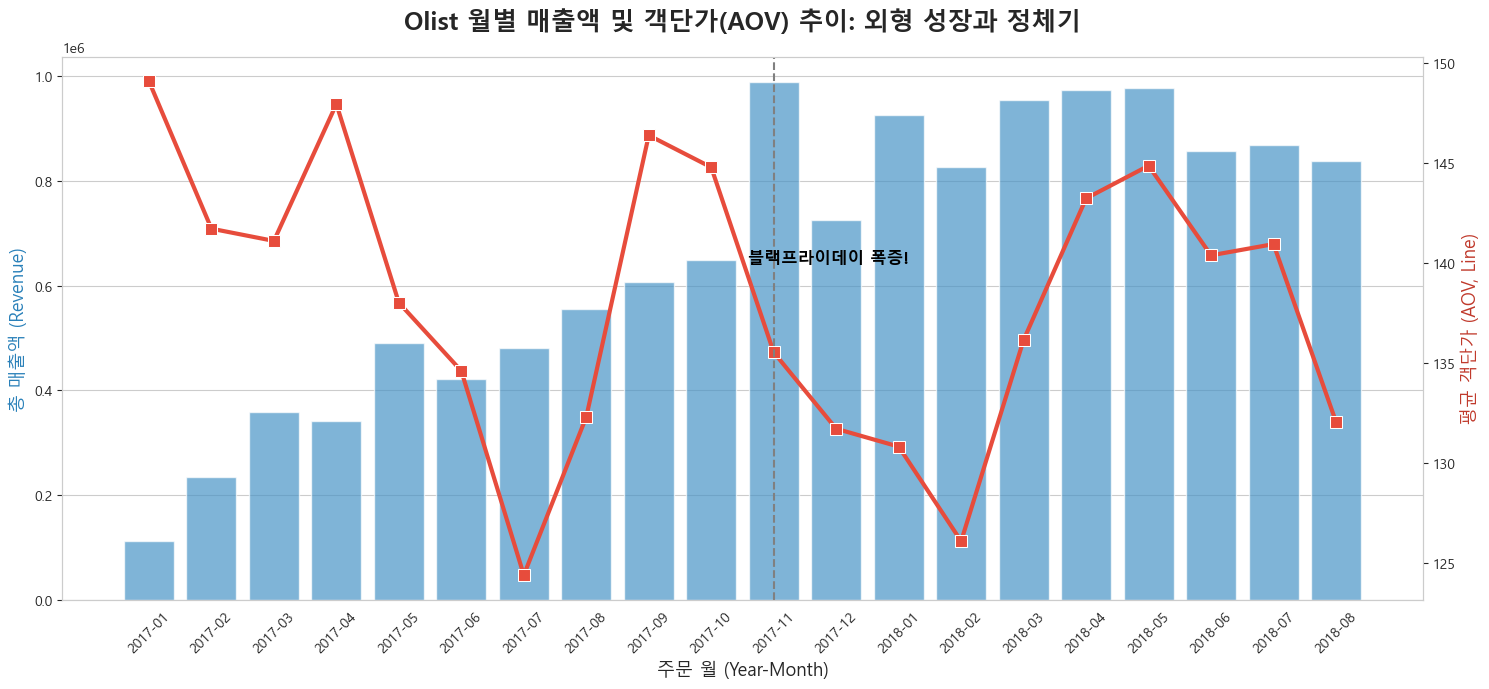

In [21]:
# ---------------------------------------------------------
# [셀 2] Chapter 1. 문제 제기: 월별 매출액(Bar)과 평균 객단가(Line) 흐름
# ---------------------------------------------------------

# 1. 월별 데이터 집계 (YYYY-MM 형태로 변환)
df['order_month_str'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m')

# 월별 매출 합계와 주문 건수 계산
monthly_df = df.groupby('order_month_str').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

# 객단가(AOV) 계산 = 총 매출 / 총 주문건수
monthly_df['AOV'] = monthly_df['total_revenue'] / monthly_df['order_count']

# 분석 기간 필터링 (2017년 1월 ~ 2018년 8월)
monthly_viz = monthly_df[(monthly_df['order_month_str'] >= '2017-01') & (monthly_df['order_month_str'] <= '2018-08')]

# 2. 콤보 차트 그리기 (축이 2개 필요합니다!)
fig, ax1 = plt.subplots(figsize=(15, 7))

# 막대 차트: 월별 총 매출 (기본 Y축, ax1)
sns.barplot(data=monthly_viz, x='order_month_str', y='total_revenue', color='#3498db', alpha=0.7, ax=ax1)
ax1.set_xlabel('주문 월 (Year-Month)', fontsize=13)
ax1.set_ylabel('총 매출액 (Revenue)', fontsize=13, color='#2980b9')
ax1.tick_params(axis='x', rotation=45) # X축 글자 안 겹치게 기울이기

# 선 차트: 객단가 (보조 Y축, ax2 생성)
ax2 = ax1.twinx() 
sns.lineplot(data=monthly_viz, x='order_month_str', y='AOV', color='#e74c3c', marker='s', linewidth=3, markersize=8, ax=ax2)
ax2.set_ylabel('평균 객단가 (AOV, Line)', fontsize=13, color='#c0392b')

# 2017년 11월 블랙프라이데이 하이라이트 표시
plt.axvline(x=10, color='gray', linestyle='--', linewidth=1.5) # 17년 11월의 인덱스 위치(10)
plt.text(9.5, 140, ' 블랙프라이데이 폭증!', fontsize=12, fontweight='bold', color='black')

plt.title('Olist 월별 매출액 및 객단가(AOV) 추이: 외형 성장과 정체기', fontsize=18, fontweight='bold', pad=20)
plt.grid(False) # 축이 2개라 헷갈리므로 그리드는 끕니다.
plt.tight_layout()
plt.show()

 [통계 검증 결과]
▶ 배송 일수와 리뷰 점수의 상관계수: -0.305
▶ P-value: 0.000e+00
 해석: 상관계수가 마이너스(-)이므로 배송이 길어질수록 평점은 떨어집니다.
 해석: P-value가 0.05보다 한참 작으므로 이 결과는 100% 통계적으로 유의미한 팩트입니다.



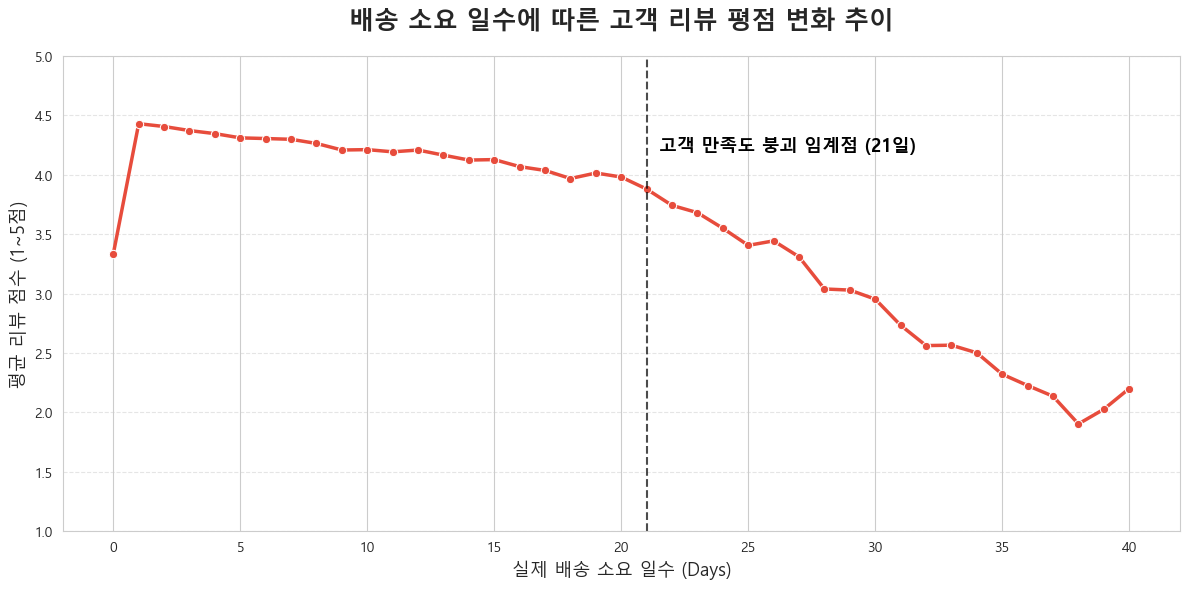

In [18]:
# [시각화 1] 

# ---------------------------------------------------------
# STEP 1. 데이터 준비 (배송 소요 일수 계산)
# ---------------------------------------------------------
# 도착일 - 구매일 = 실제 걸린 일 
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 배송이 아직 안 됐거나(NaN), 리뷰 점수가 없는 데이터는 분석을 위해 잠시 제외
analysis_df = df.dropna(subset=['delivery_days', 'review_score']).copy()

# 시각화할 때 가독성을 위해 40일 이내에 도착한 데이터만 확인 (극단적인 이상치 제외)
viz_df = analysis_df[analysis_df['delivery_days'] <= 40]


# ---------------------------------------------------------
# STEP 2. 통계적 팩트 체크 (피어슨 상관관계 분석)
# ---------------------------------------------------------
# 배송 일수와 리뷰 점수 사이의 상관계수(r)와 P-value를 계산
corr, p_value = stats.pearsonr(analysis_df['delivery_days'], analysis_df['review_score'])

print(" [통계 검증 결과]")
print(f"▶ 배송 일수와 리뷰 점수의 상관계수: {corr:.3f}")
print(f"▶ P-value: {p_value:.3e}")
print(" 해석: 상관계수가 마이너스(-)이므로 배송이 길어질수록 평점은 떨어집니다.")
print(" 해석: P-value가 0.05보다 한참 작으므로 이 결과는 100% 통계적으로 유의미한 팩트입니다.\n")


# ---------------------------------------------------------
# STEP 3. 시각화 (면접관의 뼈를 때리는 꺾은선 그래프)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# 선 그래프 그리기 (일수별 '평균' 리뷰 점수를 선으로 이어줌)
sns.lineplot(
    data=viz_df, 
    x='delivery_days', 
    y='review_score', 
    estimator='mean', # 평균값 기준
    errorbar=None,    # 그림자 제거로 깔끔하게
    color='#e74c3c',  # 강렬한 경고의 의미로 빨간색
    linewidth=2.5,
    marker='o'        # 각 날짜마다 동그라미 포인트
)

# 우리가 SQL에서 발견한 '21일 마지노선'에 시각적 포인트(점선)
plt.axvline(x=21, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(21.5, 4.2, '고객 만족도 붕괴 임계점 (21일)', fontsize=13, fontweight='bold', color='black')

# 그래프 예쁘게 꾸미기
plt.title('배송 소요 일수에 따른 고객 리뷰 평점 변화 추이', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('실제 배송 소요 일수 (Days)', fontsize=13)
plt.ylabel('평균 리뷰 점수 (1~5점)', fontsize=13)
plt.ylim(1, 5) # Y축은 점수니까 1점에서 5점까지만 픽스
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

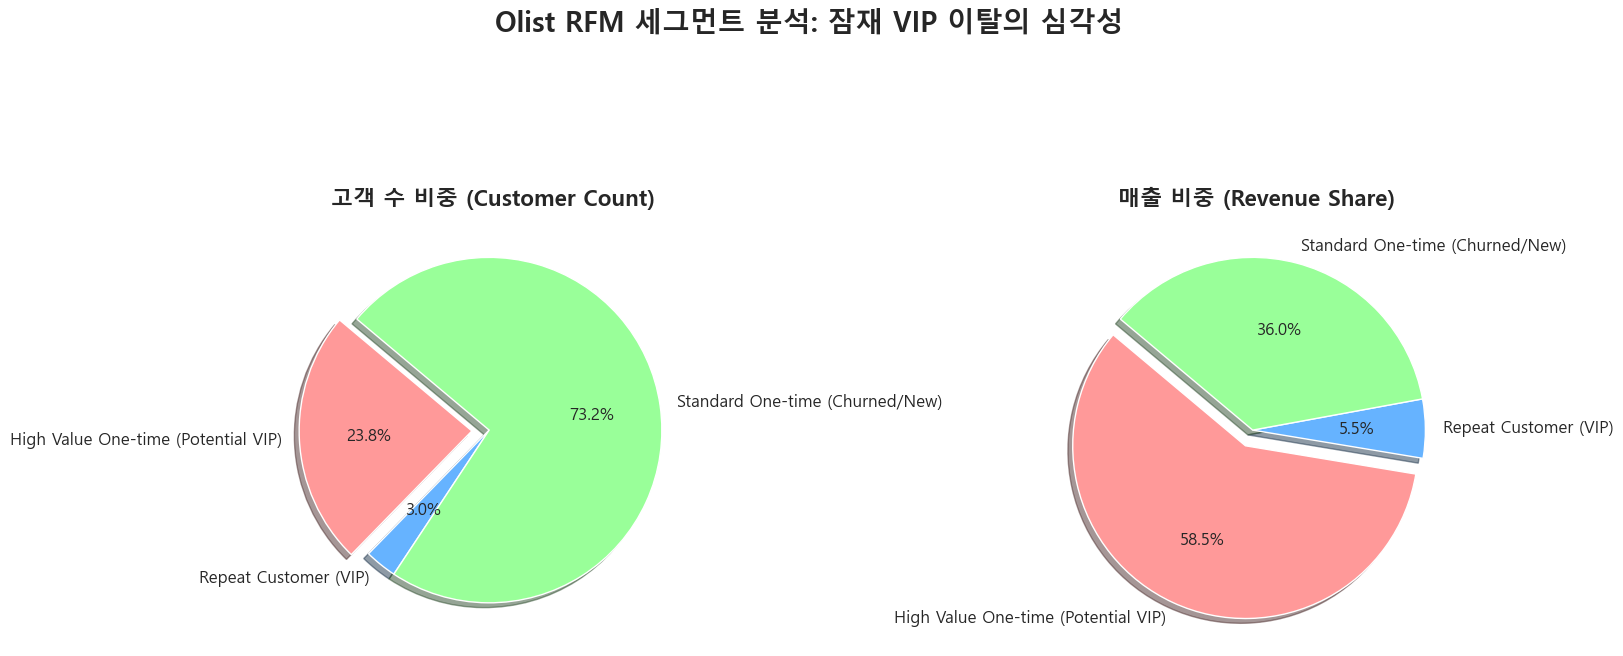

In [19]:
# ---------------------------------------------------------
# [시각화 2] RFM 파이 차트: 고객 비중 vs 매출 비중
# ---------------------------------------------------------

# 1. 파이썬으로 RFM 세그먼트 다시 집계하기 
rfm_df = df.groupby('customer_unique_id').agg(
    frequency_cnt=('order_id', 'nunique'),
    monetary_value=('price', 'sum')
).reset_index()

# 세그먼트 나누기 로직 (SQL과 동일)
def get_segment(row):
    if row['frequency_cnt'] >= 2:
        return 'Repeat Customer (VIP)'
    elif row['monetary_value'] >= 150:
        return 'High Value One-time (Potential VIP)'
    else:
        # 시간 관계상 최근/이탈은 합쳐서 '일반 1회성 고객'으로 통일하여 가독성을 높입니다.
        return 'Standard One-time (Churned/New)'

rfm_df['customer_segment'] = rfm_df.apply(get_segment, axis=1)

# 2. 세그먼트별 고객 수와 매출액 합계 구하기
segment_summary = rfm_df.groupby('customer_segment').agg(
    total_customers=('customer_unique_id', 'count'),
    total_revenue=('monetary_value', 'sum')
).reset_index()

# 3. 예쁜 파이 차트 2개 나란히 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.1, 0, 0) # High Value 그룹만 살짝 튀어나오게 강조

# 왼쪽 차트: 고객 수 비중
axes[0].pie(segment_summary['total_customers'], labels=segment_summary['customer_segment'], 
            autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True, textprops={'fontsize': 12})
axes[0].set_title(' 고객 수 비중 (Customer Count)', fontsize=16, fontweight='bold')

# 오른쪽 차트: 매출 비중
axes[1].pie(segment_summary['total_revenue'], labels=segment_summary['customer_segment'], 
            autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True, textprops={'fontsize': 12})
axes[1].set_title(' 매출 비중 (Revenue Share)', fontsize=16, fontweight='bold')

plt.suptitle('Olist RFM 세그먼트 분석: 잠재 VIP 이탈의 심각성', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()